In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("dark_background")

# Functions

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# GRAPH FACTORIES
# ══════════════════════════════════════════════════════════════════════════════

def make_line(n):
    return nx.path_graph(n)

def make_grid_2d(n):
    return nx.grid_2d_graph(n, n)

def make_grid_3d(n):
    return nx.grid_graph(dim=[n, n, n])

def make_spherical_graph(n_points=300, angle_threshold_deg=15, seed=42):
    """Sample unit vectors on S^2, connect if angle between them < threshold."""
    rng  = np.random.default_rng(seed)
    vecs = rng.normal(size=(n_points, 3))
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
    threshold = np.cos(np.radians(angle_threshold_deg))
    G = nx.Graph()
    G.add_nodes_from(range(n_points))
    for i in range(n_points):
        for j in range(i + 1, n_points):
            if np.dot(vecs[i], vecs[j]) >= threshold:
                G.add_edge(i, j)
    nx.set_node_attributes(G, {i: vecs[i] for i in range(n_points)}, 'pos')
    return G, vecs

def make_community_graph(n_nodes, n_communities, p_intra, p_inter, seed=None):
    """Stochastic block model with equal-sized communities."""
    sizes = [n_nodes // n_communities] * n_communities
    for i in range(n_nodes % n_communities):
        sizes[i] += 1
    probs = np.full((n_communities, n_communities), p_inter)
    np.fill_diagonal(probs, p_intra)
    G      = nx.stochastic_block_model(sizes, probs, seed=seed)
    labels = [comm for comm, size in enumerate(sizes) for _ in range(size)]
    return G, labels

# ══════════════════════════════════════════════════════════════════════════════
# GRAPH DRAW HELPERS  (uniform signature: G, ax, **kw)
# ══════════════════════════════════════════════════════════════════════════════

def draw_line(G, ax, **kw):
    pos = {i: (i, 0) for i in G.nodes()}
    nx.draw_networkx(G, pos, ax=ax, node_size=50, node_color='red',
                     edge_color='white', with_labels=False, arrows=False)
    ax.set_title("1D Grid", fontsize=14)
    ax.axis('off')

def draw_grid_2d(G, ax, **kw):
    pos = {(x, y): (x, y) for x, y in G.nodes()}
    nx.draw_networkx(G, pos, ax=ax, node_size=30, node_color='royalblue',
                     edge_color='white', with_labels=False, arrows=False)
    ax.set_title("2D Grid", fontsize=14)
    ax.axis('off')

def draw_grid_3d(G, ax, **kw):
    xs, ys, zs = zip(*G.nodes())
    ax.scatter(xs, ys, zs, c='limegreen', s=20, alpha=0.6)
    for u, v in G.edges():
        ax.plot([u[0],v[0]], [u[1],v[1]], [u[2],v[2]],
                color='white', alpha=0.5, linewidth=0.5)
    ax.set_title("3D Grid", fontsize=14)
    ax.set_axis_off()

def draw_spring(G, ax, node_colors=None, color='steelblue',
                pos=None, title="Graph", **kw):
    """Generic spring-layout draw; used for community graph, Wikipedia, etc."""
    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=1.5)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors if node_colors is not None else color,
                           node_size=40, alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color='white', alpha=0.4, width=0.5)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

def draw_spherical_qt(G, vecs, color='orange'):
    """Opens an interactive Qt window — call in its own cell."""
    fig = plt.figure(figsize=(8, 8))
    ax  = fig.add_subplot(111, projection='3d')
    xs, ys, zs = vecs[:, 0], vecs[:, 1], vecs[:, 2]
    ax.scatter(xs, ys, zs, c=color, s=30, alpha=0.8)
    for u, v in G.edges():
        ax.plot([vecs[u,0], vecs[v,0]],
                [vecs[u,1], vecs[v,1]],
                [vecs[u,2], vecs[v,2]],
                color='white', alpha=0.4, linewidth=0.4)
    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
    ax.set_box_aspect([1,1,1])
    ax.set_axis_off()
    ax.set_title("Spherical Graph — drag to rotate", fontsize=13)
    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# DIMENSION ESTIMATION CORE
# ══════════════════════════════════════════════════════════════════════════════

def ball_size(G, center, r):
    return len(nx.single_source_shortest_path_length(G, center, cutoff=r))

def measure_ball_growth(G, center, max_r):
    radii = np.arange(1, max_r + 1)
    sizes = np.array([ball_size(G, center, r) for r in radii])
    return radii, sizes

def fit_dimension(radii, sizes, min_r_fit=3, max_r_fit=None):
    """
    Fit |B(r)| ~ r^d in log-log space using only r in [min_r_fit, max_r_fit].

    min_r_fit : exclude small r (discretisation noise / integer lattice artefacts)
    max_r_fit : exclude large r (boundary effects where ball hits graph edge)
    Both are radius values, not indices.
    """
    mask = radii >= min_r_fit
    if max_r_fit is not None:
        mask &= radii <= max_r_fit
    d, _ = np.polyfit(np.log(radii[mask]), np.log(sizes[mask]), 1)
    return d

def get_interior_centers(G, n_centers, boundary_frac=0.25, seed=42):
    """Return nodes with the lowest average shortest-path distance (most interior)."""
    rng      = np.random.default_rng(seed)
    nodes    = list(G.nodes())
    avg_dist = {n: np.mean(list(nx.single_source_shortest_path_length(G, n).values()))
                for n in nodes}
    cutoff   = np.quantile(list(avg_dist.values()), boundary_frac)
    interior = [n for n, d in avg_dist.items() if d <= cutoff]
    idx      = rng.choice(len(interior), size=min(n_centers, len(interior)), replace=False)
    return [interior[i] for i in idx]

# ══════════════════════════════════════════════════════════════════════════════
# SHARED PLOT HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _add_fit_region(ax, min_r_fit, max_r_fit, log_scale=False):
    """Shade the fitting window and draw min/max boundary lines."""
    lo = np.log(min_r_fit) if log_scale else min_r_fit
    hi = np.log(max_r_fit) if log_scale else max_r_fit
    ax.axvline(lo, color='yellow', linestyle='--', linewidth=1.5, alpha=0.9,
               label=f"min r = {min_r_fit}")
    ax.axvline(hi, color='orange', linestyle='--', linewidth=1.5, alpha=0.9,
               label=f"max r = {max_r_fit}")
    ax.axvspan(lo, hi, alpha=0.07, color='yellow')

def _add_mean_fit_line(ax, centers, G, max_r, mean_d, min_r_fit, max_r_fit):
    """Overlay the mean fitted power-law slope on log-log axes."""
    all_radii, all_sizes = zip(*[measure_ball_growth(G, c, max_r) for c in centers])
    mean_sizes = np.mean(all_sizes, axis=0)
    fit_radii  = all_radii[0]
    mask       = (fit_radii >= min_r_fit) & (fit_radii <= max_r_fit)
    c_fit      = (np.mean(np.log(mean_sizes[mask])) -
                  mean_d * np.mean(np.log(fit_radii[mask])))
    lr         = np.linspace(np.log(fit_radii[mask][0]),
                              np.log(fit_radii[mask][-1]), 200)
    ax.plot(lr, mean_d * lr + c_fit, '-', color='white', linewidth=2.5,
            label=f"slope = {mean_d:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# UNIFIED SINGLE-GRAPH DEMO  —  graph | ball growth | log-log
# ══════════════════════════════════════════════════════════════════════════════

def demo_dimension(G, draw_fn, color='steelblue',
                   max_r=8, min_r_fit=3, max_r_fit=4,
                   n_centers=10, title="Graph", graph_name=None,
                   is_3d=False, draw_kw=None):
    """
    3-column dimension demo for a single graph.

    Parameters
    ----------
    draw_fn    : callable(G, ax, **draw_kw)
    draw_kw    : extra kwargs forwarded to draw_fn
    graph_name : label used in the output DataFrame (defaults to title)
    """
    if graph_name is None:
        graph_name = title
    if draw_kw is None:
        draw_kw = {}

    fig      = plt.figure(figsize=(21, 6))
    ax_graph = fig.add_subplot(1, 3, 1, projection='3d' if is_3d else None)
    ax_lin   = fig.add_subplot(1, 3, 2)
    ax_log   = fig.add_subplot(1, 3, 3)

    draw_fn(G, ax_graph, **draw_kw)

    centers = get_interior_centers(G, n_centers)
    records = []
    all_d   = []

    for center in centers:
        radii, sizes = measure_ball_growth(G, center, max_r)
        sat = np.argmax(sizes == G.number_of_nodes())
        if sat > 0 and sat < min_r_fit:
            continue
        d_fit = fit_dimension(radii, sizes, min_r_fit=min_r_fit, max_r_fit=max_r_fit)
        all_d.append(d_fit)
        records.append({"graph": graph_name, "seed": str(center), "fitted_d": d_fit})
        ax_lin.plot(radii,         sizes,         color=color, alpha=0.4, linewidth=1.5)
        ax_log.plot(np.log(radii), np.log(sizes), color=color, alpha=0.4, linewidth=1.5)

    mean_d = np.mean(all_d)
    std_d  = np.std(all_d)

    _add_mean_fit_line(ax_log, centers, G, max_r, mean_d, min_r_fit, max_r_fit)
    _add_fit_region(ax_lin, min_r_fit, max_r_fit, log_scale=False)
    _add_fit_region(ax_log, min_r_fit, max_r_fit, log_scale=True)

    ax_lin.set_title("Ball Growth",            fontsize=13)
    ax_lin.set_xlabel("Radius $r$"); ax_lin.set_ylabel("$|B(r)|$")
    ax_lin.legend(fontsize=9)

    ax_log.set_title("Log-Log  (slope = $d$)", fontsize=13)
    ax_log.set_xlabel("$\\log(r)$"); ax_log.set_ylabel("$\\log(|B(r)|)$")
    ax_log.legend(fontsize=9)

    plt.suptitle(f"{title} — fitted $d$ = {mean_d:.2f} ± {std_d:.2f}", fontsize=15)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(records)
    display(df.groupby("graph")["fitted_d"].describe().round(3))
    return df

# ══════════════════════════════════════════════════════════════════════════════
# MULTI-GRAPH DEMO  —  3-row layout (graph / ball growth / log-log) per graph
# ══════════════════════════════════════════════════════════════════════════════

def demo_dimension_grid(graphs, max_r, min_r_fit=3, max_r_fit=None, n_centers=8):
    """
    graphs : list of (G, title, color, draw_fn, is_3d)
    Produces a (3 × n_graphs) figure and a summary DataFrame.
    """
    n   = len(graphs)
    fig = plt.figure(figsize=(7 * n, 20))
    ax  = {}
    for col, (G, title, color, draw_fn, is_3d) in enumerate(graphs):
        ax[(0,col)] = fig.add_subplot(3, n, col + 1,         projection='3d' if is_3d else None)
        ax[(1,col)] = fig.add_subplot(3, n, n     + col + 1)
        ax[(2,col)] = fig.add_subplot(3, n, 2 * n + col + 1)

    records = []
    for col, (G, title, color, draw_fn, is_3d) in enumerate(graphs):
        draw_fn(G, ax[(0,col)])

        centers = get_interior_centers(G, n_centers)
        all_d   = []

        for center in centers:
            radii, sizes = measure_ball_growth(G, center, max_r)
            d_fit        = fit_dimension(radii, sizes,
                                         min_r_fit=min_r_fit, max_r_fit=max_r_fit)
            all_d.append(d_fit)
            records.append({"graph": title, "seed": str(center), "fitted_d": d_fit})
            ax[(1,col)].plot(radii,         sizes,         color=color, alpha=0.4, linewidth=1.5)
            ax[(2,col)].plot(np.log(radii), np.log(sizes), color=color, alpha=0.4, linewidth=1.5)

        mean_d = np.mean(all_d)
        std_d  = np.std(all_d)

        _add_mean_fit_line(ax[(2,col)], centers, G, max_r, mean_d, min_r_fit, max_r_fit)
        _add_fit_region(ax[(1,col)], min_r_fit, max_r_fit, log_scale=False)
        _add_fit_region(ax[(2,col)], min_r_fit, max_r_fit, log_scale=True)

        ax[(0,col)].set_title(f"{title}\n$d$ = {mean_d:.2f} ± {std_d:.2f}", fontsize=12)

        ax[(1,col)].set_title(f"{title}\nBall Growth",            fontsize=12)
        ax[(1,col)].set_xlabel("Radius $r$"); ax[(1,col)].set_ylabel("$|B(r)|$")
        ax[(1,col)].legend(fontsize=9)

        ax[(2,col)].set_title(f"{title}\nLog-Log  (slope = $d$)", fontsize=12)
        ax[(2,col)].set_xlabel("$\\log(r)$"); ax[(2,col)].set_ylabel("$\\log(|B(r)|)$")
        ax[(2,col)].legend(fontsize=9)

    plt.suptitle("Graph Dimension:  $|B(r)| \\sim r^d$", fontsize=18, y=1.01)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(records)
    display(df.groupby("graph")["fitted_d"].describe().round(3))
    return df

# Grid graphs

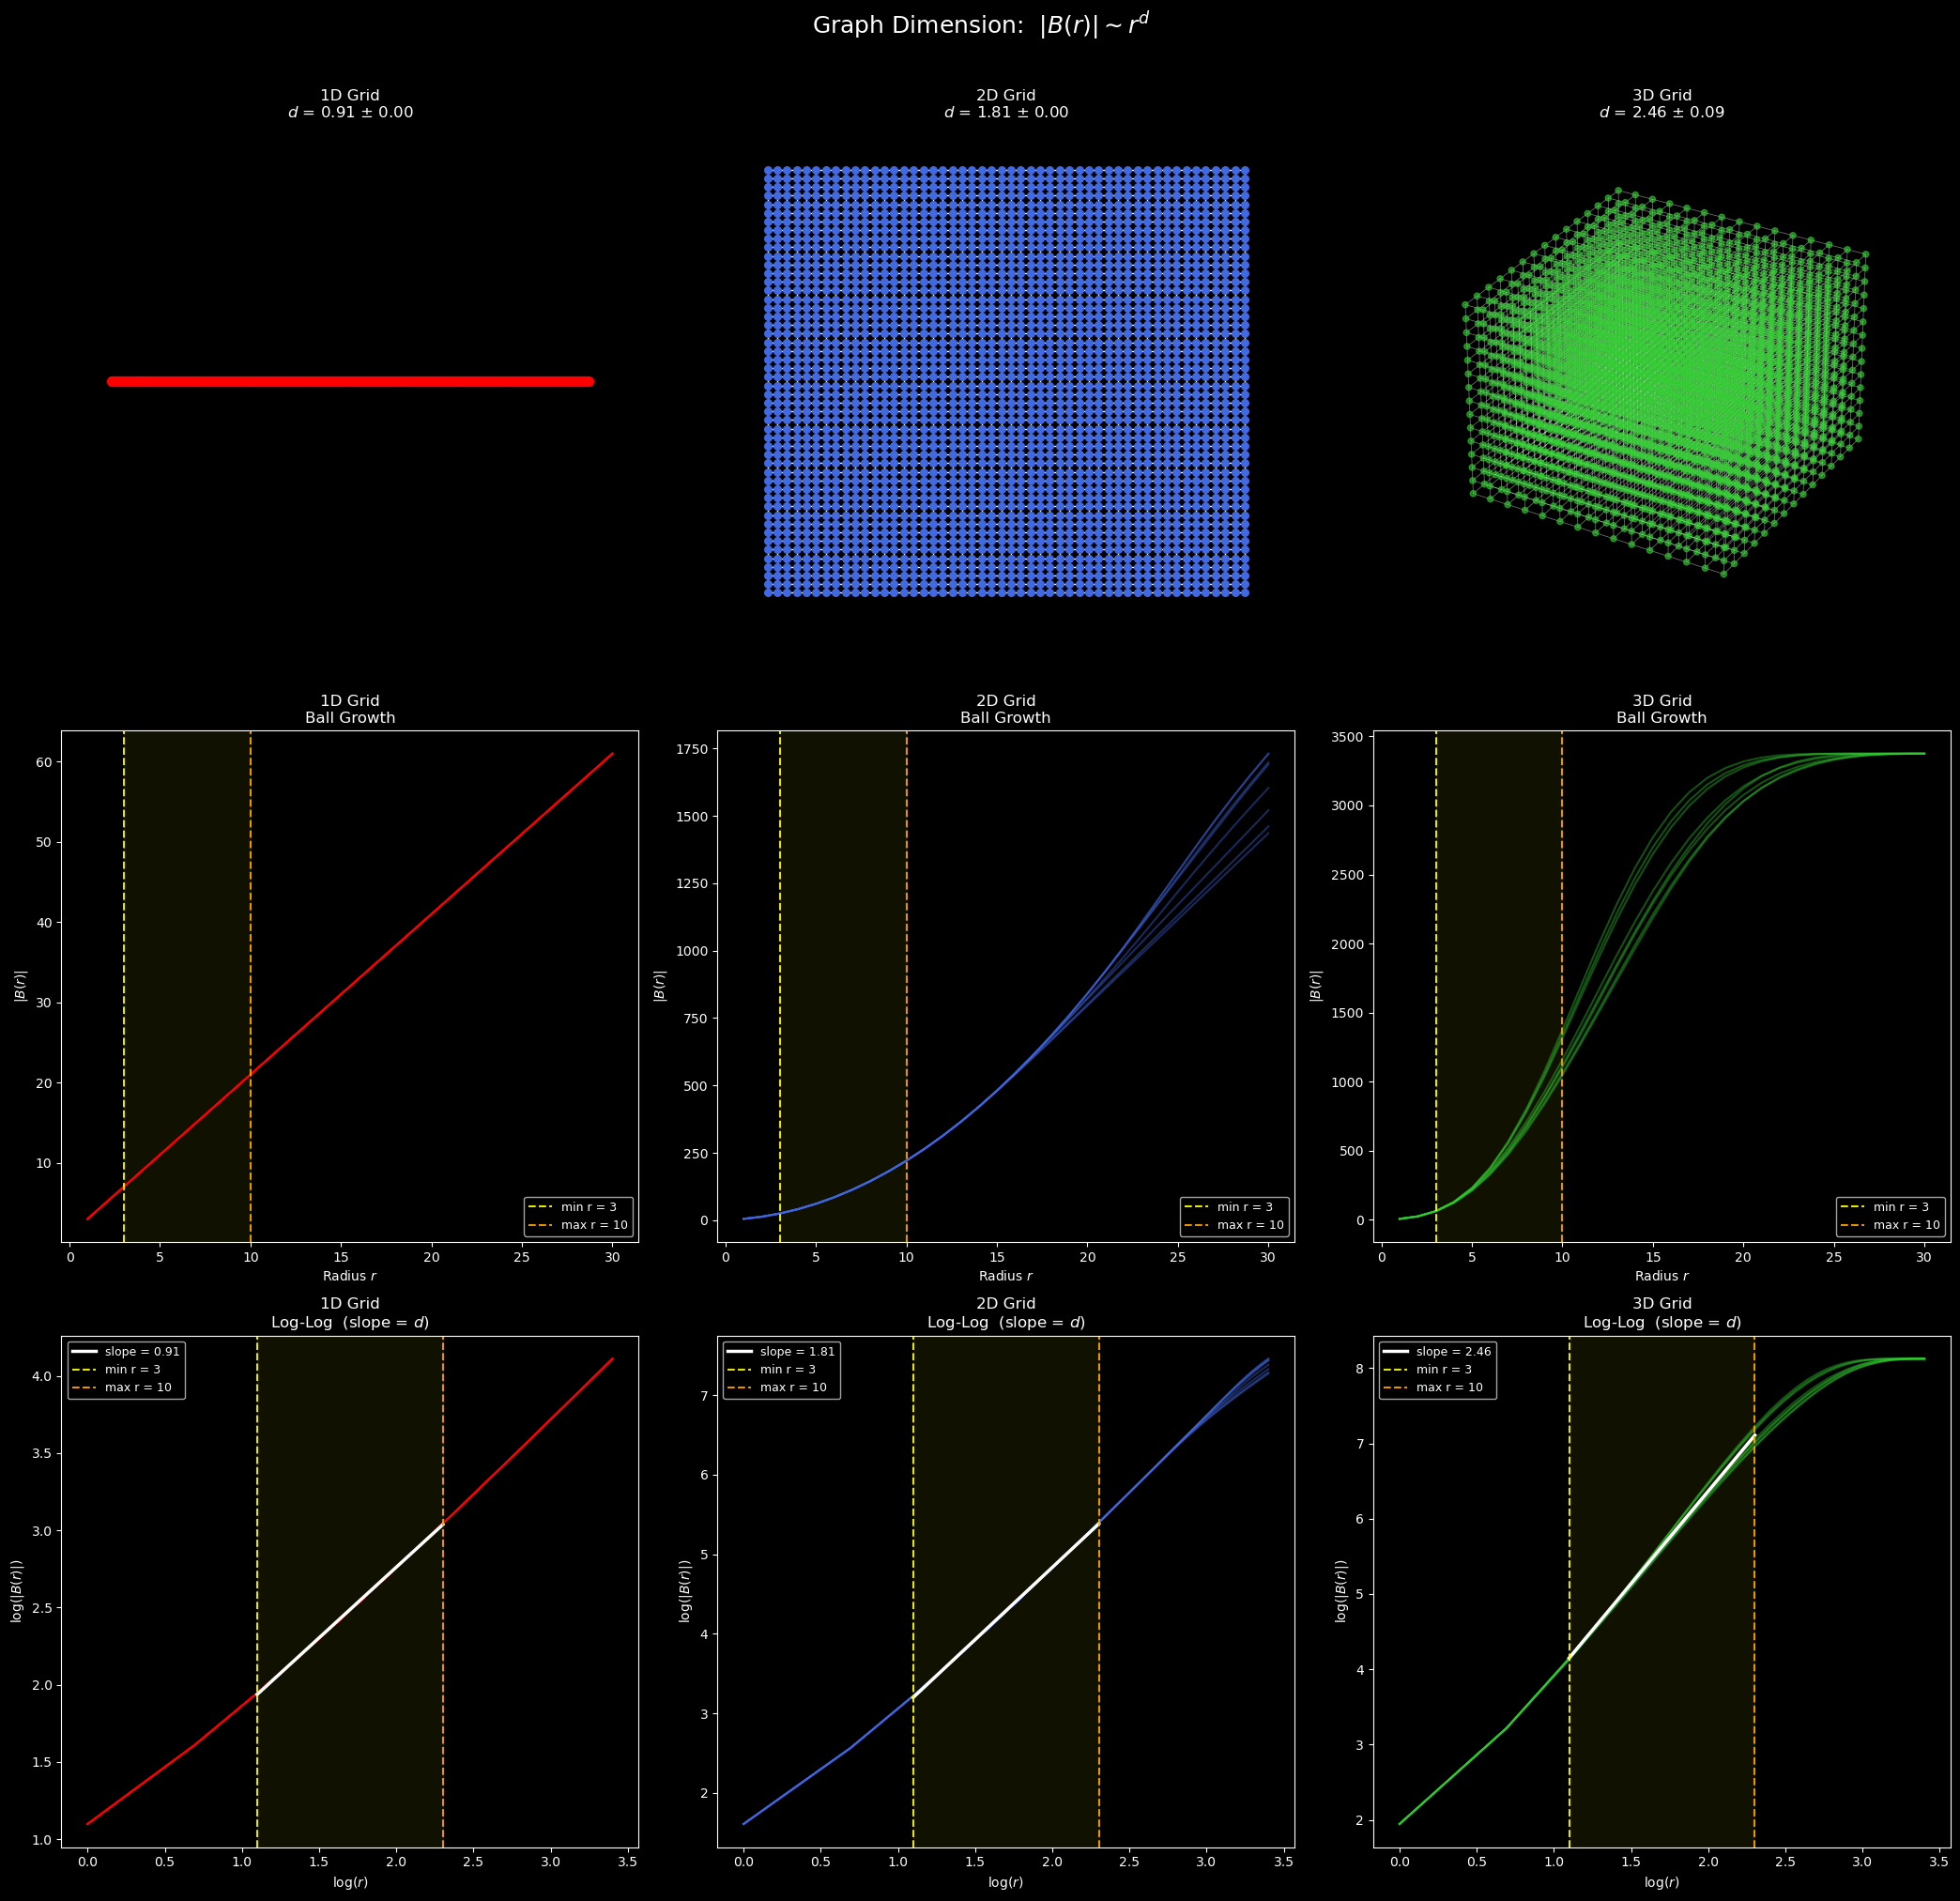

,count,mean,std,min,25%,50%,75%,max
graph,,,,,,,,
1D Grid,8.0,0.914,0.000,0.914,0.914,0.914,0.914,0.914
2D Grid,8.0,1.814,0.000,1.814,1.814,1.814,1.814,1.814
3D Grid,8.0,2.458,0.094,2.355,2.383,2.429,2.551,2.587


In [3]:
# ── Grid graphs ───────────────────────────────────────────────────────────────
G_line = make_line(500)
G_2d   = make_grid_2d(50)
G_3d   = make_grid_3d(15)

df_grids = demo_dimension_grid(
    graphs = [
        (G_line, "1D Grid", "red",       draw_line,    False),
        (G_2d,   "2D Grid", "royalblue", draw_grid_2d, False),
        (G_3d,   "3D Grid", "limegreen", draw_grid_3d, True),
    ],
    max_r     = 30,
    min_r_fit = 3,
    max_r_fit = 10,
    n_centers = 8,
)

# Spherical graph

In [7]:
# ── Spherical graph ───────────────────────────────────────────────────────────
G_sphere, vecs = make_spherical_graph(n_points=500, angle_threshold_deg=15, seed=42)
print(f"Sphere — Nodes: {G_sphere.number_of_nodes()}, "
      f"Edges: {G_sphere.number_of_edges()}, "
      f"Connected: {nx.is_connected(G_sphere)}")

# ── Cell B: run alone so Qt window stays open ─────────────────────────────────
%matplotlib qt
plt.style.use("dark_background")
draw_spherical_qt(G_sphere, vecs, color='orange')

Sphere — Nodes: 500, Edges: 2131, Connected: True


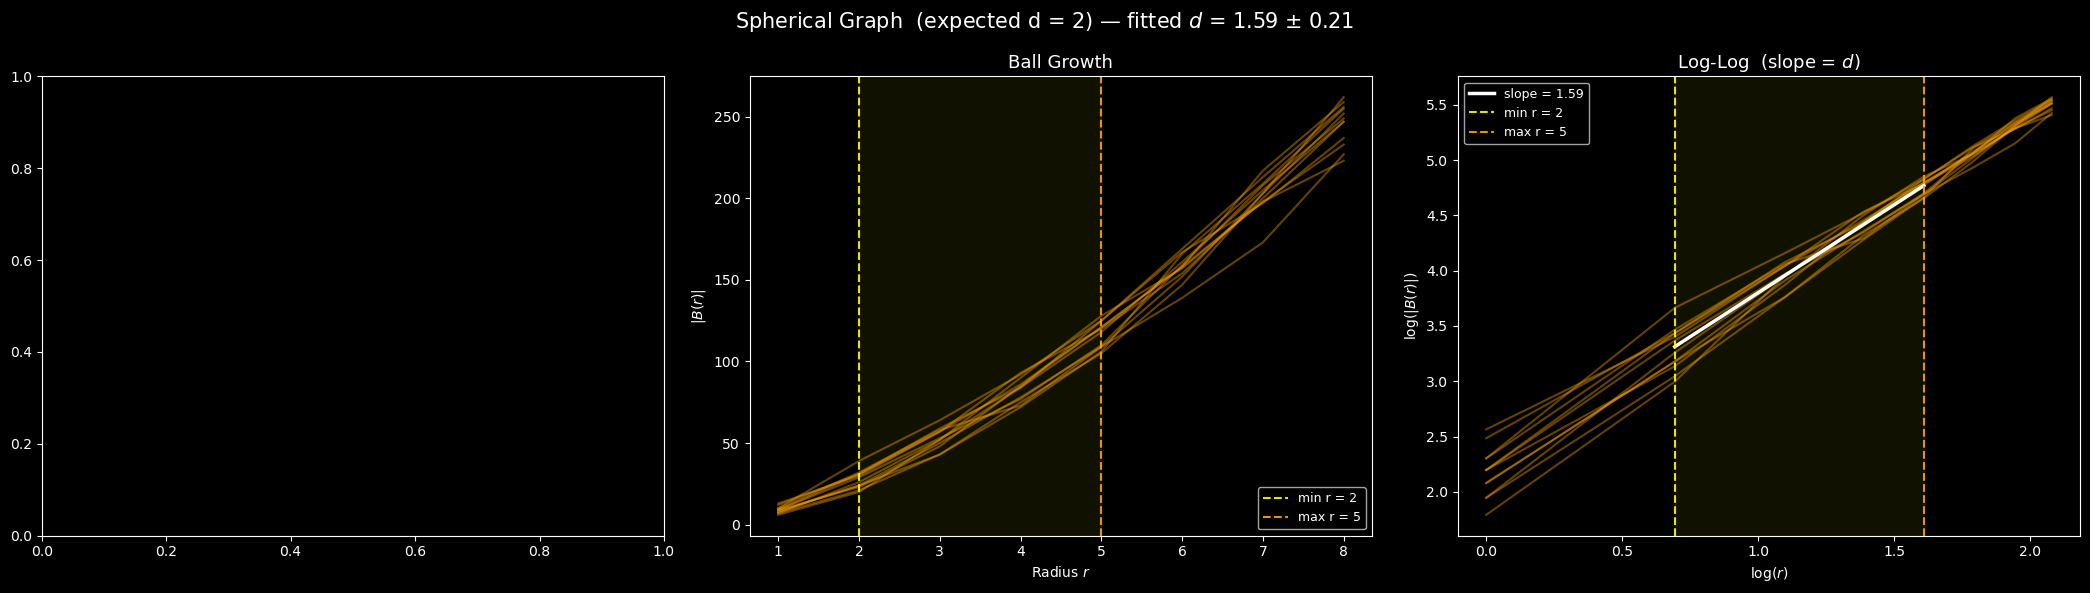

,count,mean,std,min,25%,50%,75%,max
graph,,,,,,,,
Spherical,12.0,1.591,0.222,1.266,1.441,1.571,1.762,1.989


In [8]:
%matplotlib inline
plt.style.use("dark_background")
df_sphere = demo_dimension(
    G_sphere,
    draw_fn    = lambda G, ax, **kw: None,   # swap in draw_spherical_qt for inline 3D
    color      = 'orange',
    max_r      = 8,
    min_r_fit  = 2,
    max_r_fit  = 5,
    n_centers  = 12,
    title      = "Spherical Graph  (expected d = 2)",
    graph_name = "Spherical",
)

# Community graph

Community — Nodes: 200, Edges: 1437, Connected: True


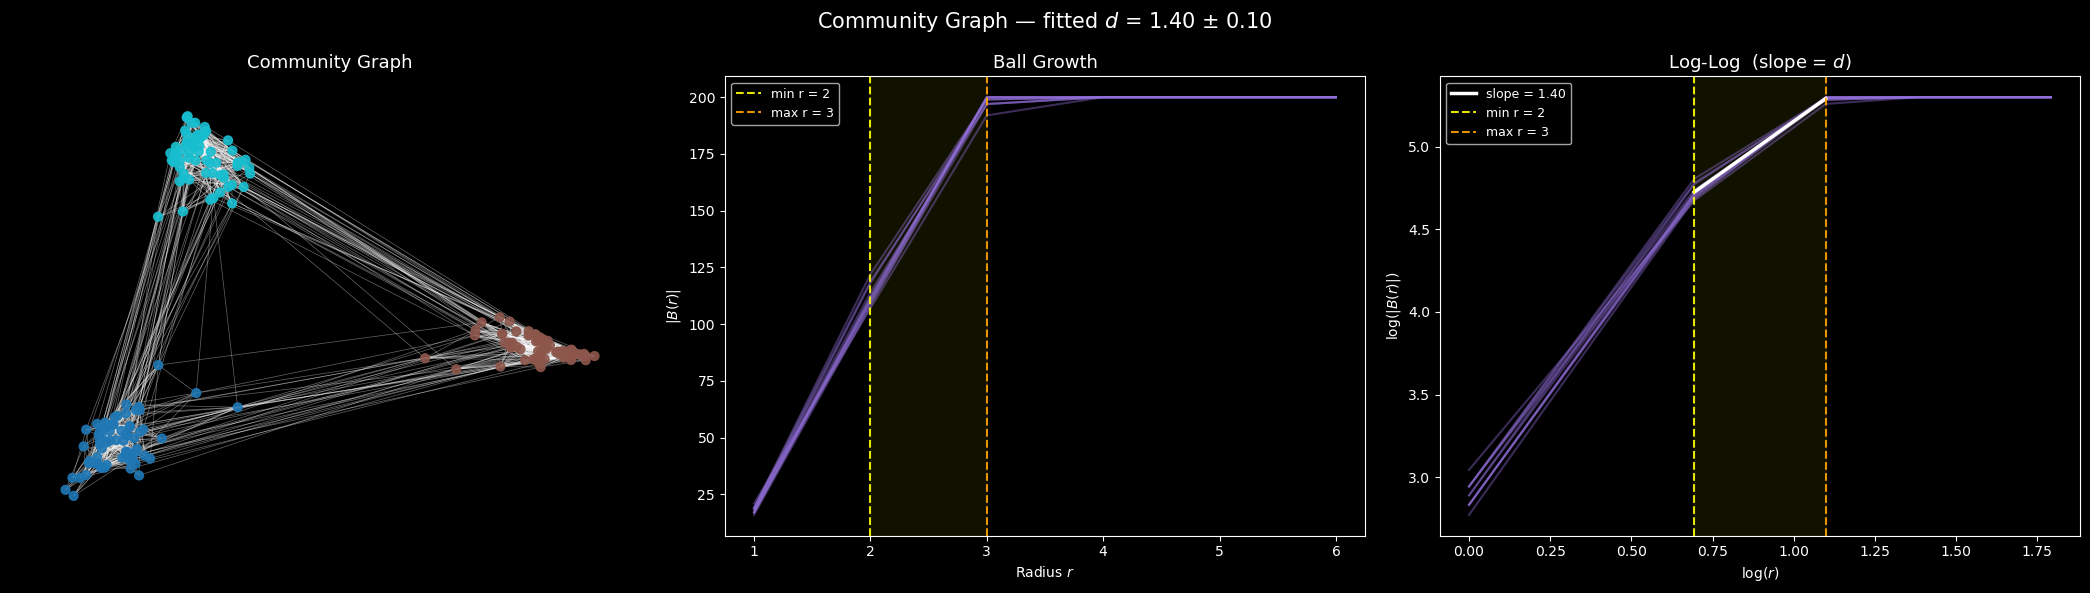

,count,mean,std,min,25%,50%,75%,max
graph,,,,,,,,
Community Graph,12.0,1.396,0.101,1.207,1.334,1.436,1.463,1.52


In [9]:
# ── Community graph ───────────────────────────────────────────────────────────
G_comm, labels = make_community_graph(
    n_nodes       = 200,
    n_communities = 3,
    p_intra       = 0.2,
    p_inter       = 0.01,
    seed          = 42,
)
print(f"Community — Nodes: {G_comm.number_of_nodes()}, "
      f"Edges: {G_comm.number_of_edges()}, "
      f"Connected: {nx.is_connected(G_comm)}")

comm_colors = plt.cm.tab10(np.array(labels) / max(labels))
pos_comm    = nx.spectral_layout(G_comm)

df_comm = demo_dimension(
    G_comm,
    draw_fn    = draw_spring,
    color      = 'mediumpurple',
    max_r      = 6,
    min_r_fit  = 2,
    max_r_fit  = 3,
    n_centers  = 12,
    title      = "Community Graph",
    draw_kw    = dict(node_colors=comm_colors, pos=pos_comm, title="Community Graph"),
)